In [1]:
# Librerías para el manejo de datos #
import os             # Interactúa con el sistema operativo (archivos, rutas)
import numpy as np    # Cálculo numérico con arrays
import pandas as pd   # Manipulación y análisis de datos
import io             # Manejo de flujos en memoria

In [2]:
# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [3]:
# Organizar las rutas de acceso a los datos #
mainpath= "/content/dataset_regresion.csv" #Cuando aparece "\" coloco r adelante
filename= "/content/dataset_regresion.csv"
fullpath= os.path.join(mainpath,filename)

In [4]:
# cargar los datos #
data = pd.read_csv(fullpath, sep=";")      # El separador es ";" porque en el archivo .csv los valores están separados por punto y coma
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame sin truncar
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Lista de las columnas del DataFrame #
data.columns.tolist()

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

### **PUNTO 2 ANÁLISIS EXPLORATORIO DE DATOS**

**2.1 Identificación de las variables:**  Acá se revisan de que tipo son las variables si son de tipo númerico o categóricas

In [6]:
data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


**2.2 Análisis descriptivo:** Media, Desviación Estándar, Min, Max, QS.

In [7]:
data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


**Interpretación:** El análisis descriptivo muestra que la base de datos cuenta con 1338 observaciones completas en todas las variables. La edad de los individuos tiene un promedio de aproximadamente 39 años, con una dispersión moderada (desviación estándar ≈ 14), lo que indica una población relativamente variada en términos de edad. El índice de masa corporal (BMI) presenta un promedio cercano a 30.66, lo cual sugiere que, en general, la población se encuentra en el rango de sobrepeso, con cierta variabilidad. En cuanto al número de hijos, el promedio es bajo (≈ 1 hijo), concentrándose la mayoría entre 0 y 2, lo que indica poca dispersión en esta variable. Finalmente, los cargos médicos (charges) muestran una alta variabilidad (desviación estándar ≈ 12110), con valores que van desde aproximadamente 1121 hasta más de 63000, lo que evidencia una distribución bastante dispersa y posiblemente sesgada hacia la derecha, sugiriendo la presencia de valores atípicos altos que podrían influir en el análisis posterior.

**2.3 Distribuciones de las variables númericas:** En los histogramas de variables numéricas se observa la forma de la distribución (simetría, sesgo, concentración de datos) y la posible presencia de valores atípicos.

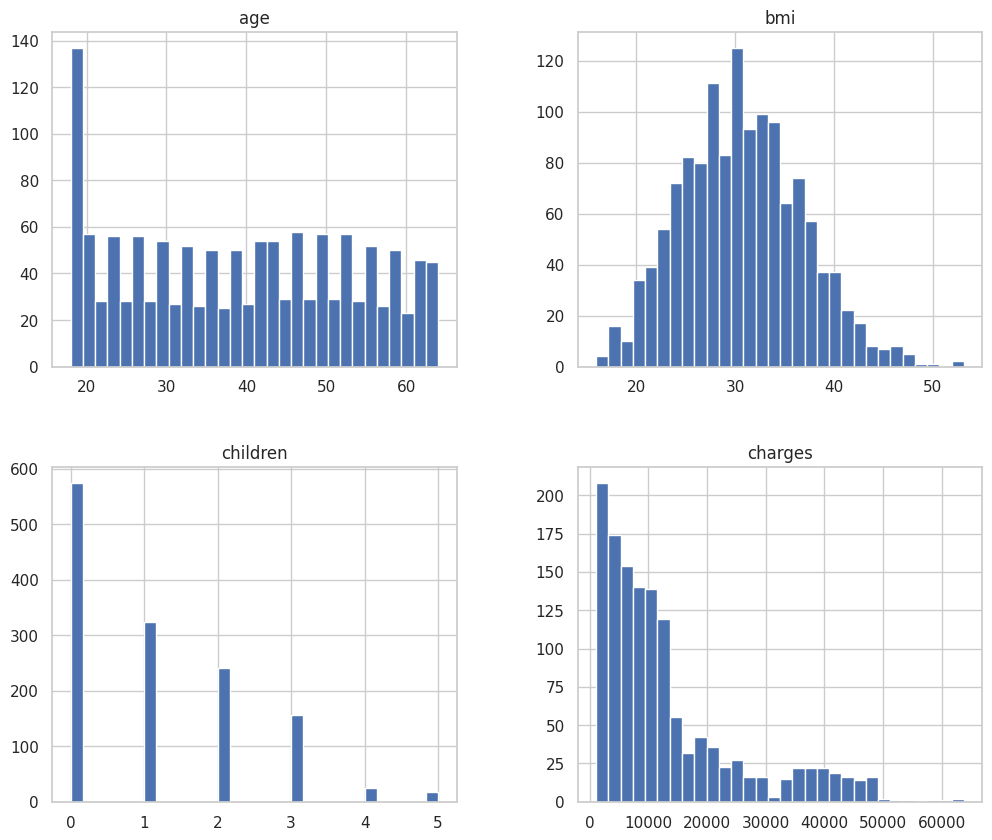

In [8]:
# Distribución de variables numéricas #
import matplotlib.pyplot as plt
data.hist(bins=30, figsize=(12,10))
plt.show()

**Iterpretación** En los histogramas se pueden identificar patrones importantes en cada variable:

* Edad (age): distribución relativamente uniforme entre 20 y 60 años, sin un sesgo fuerte, lo que indica diversidad en edades.
* BMI: presenta una forma aproximadamente normal, centrada alrededor de 30, aunque con ligera asimetría hacia la derecha.
* Hijos (children): distribución discreta, con mayor concentración en 0, 1 y 2 hijos, mostrando baja variabilidad.
* Cargos (charges): distribución fuertemente sesgada a la derecha, con muchos valores bajos y pocos muy altos, lo que sugiere presencia de valores atípicos.

En general, se observa que algunas variables (como charges) no siguen una distribución normal, lo cual es clave para el modelado posterior.

**2.4 Gráfico de densidades**

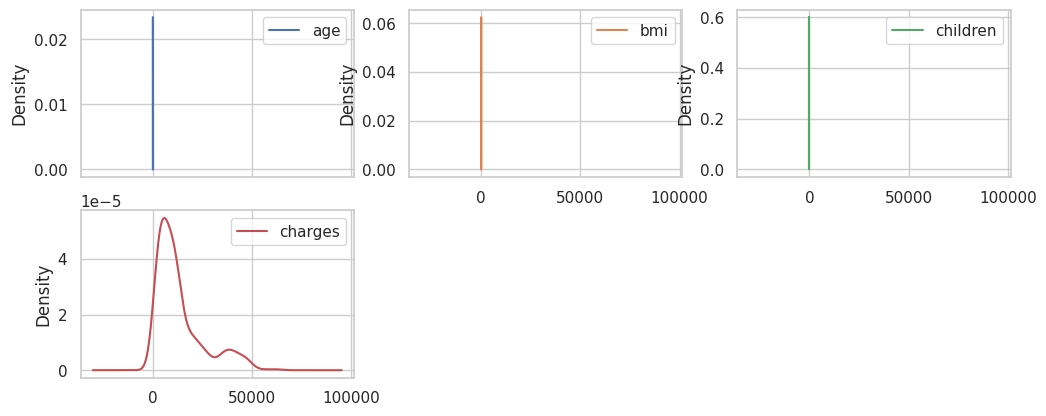

In [9]:
data.plot(kind='density', subplots=True, layout=(4,3), figsize=(12,10))
plt.show()

**Interpretación:** Age, BMI y Children: las curvas aparecen muy “aplastadas” o concentradas, lo que indica que, comparadas con charges, tienen una escala mucho menor. Aun así, se puede intuir que BMI tiene forma aproximadamente normal, mientras que children es discreta y age relativamente distribuida.
Charges: presenta una distribución claramente sesgada a la derecha, con una alta concentración en valores bajos y una cola larga hacia valores altos. Esto confirma la presencia de valores extremos (outliers) y sugiere que esta variable no sigue una distribución normal.
En conjunto, se evidencia que las variables no están en la misma escala y que charges domina la variabilidad, lo cual puede requerir transformaciones (como logaritmo) para mejorar el análisis o modelado.

**2.5 Boxplot y datos atípicos**

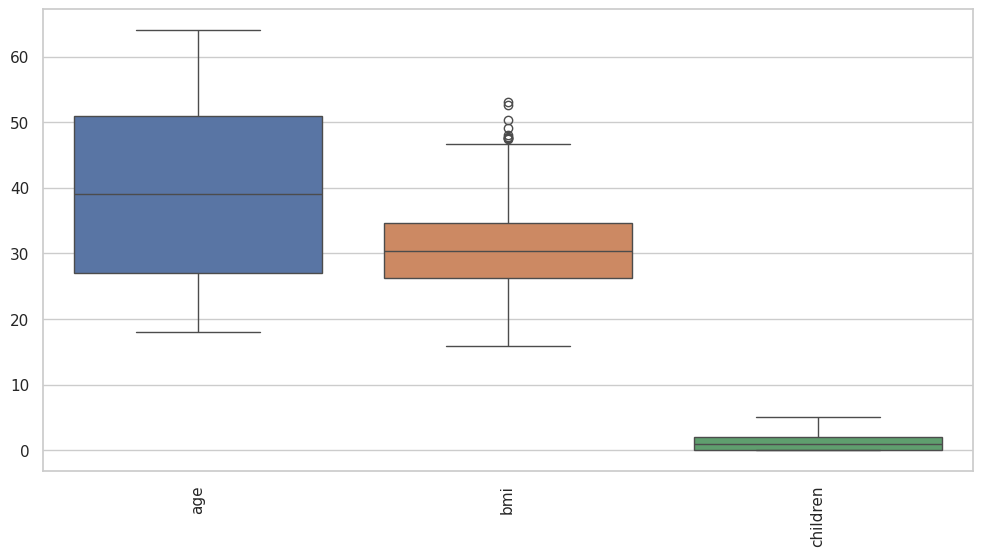

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=data[["age", "bmi", "children"]]) # Corrected columns to existing numerical ones
plt.xticks(rotation=90)
plt.show()

**Interpretación:** El análisis de los boxplots muestra que la variable edad (age) presenta una distribución relativamente amplia, sin presencia evidente de valores atípicos, lo que indica una variabilidad natural en la población. En el caso del BMI, se observan varios valores atípicos altos, lo que sugiere la existencia de individuos con índices de masa corporal significativamente elevados respecto al resto. Por su parte, la variable children presenta una distribución muy concentrada en valores bajos (principalmente entre 0 y 2), con poca dispersión y sin outliers relevantes. En conjunto, se evidencia que BMI es la variable más sensible a valores extremos, lo cual puede influir en el análisis y modelado posterior.

**Boxplot para la variable cargos**

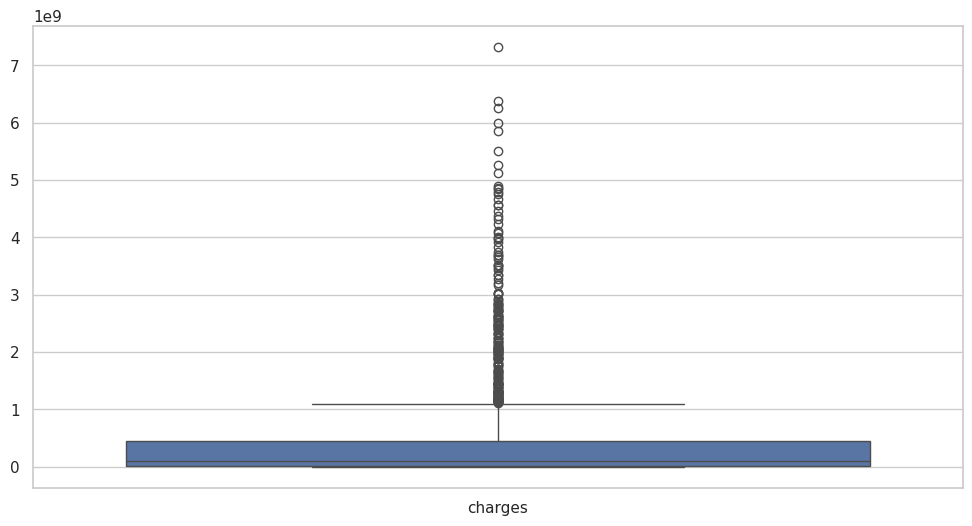

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=data[["charges"]])
plt.show()

**Interpretación:** El boxplot de la variable charges evidencia una fuerte asimetría hacia la derecha, donde la mayoría de los valores se concentran en rangos bajos, mientras que existe una gran cantidad de valores atípicos altos que se extienden considerablemente. La caja (IQR) es relativamente pequeña en comparación con la dispersión total, lo que indica que unos pocos valores extremos están influyendo significativamente en la distribución. Esto sugiere que la variable no sigue una distribución normal y que sería recomendable aplicar transformaciones (como logaritmos) o tratamientos de outliers para mejorar el análisis y el rendimiento de modelos predictivos.

**2.6 Análisis de correlación**


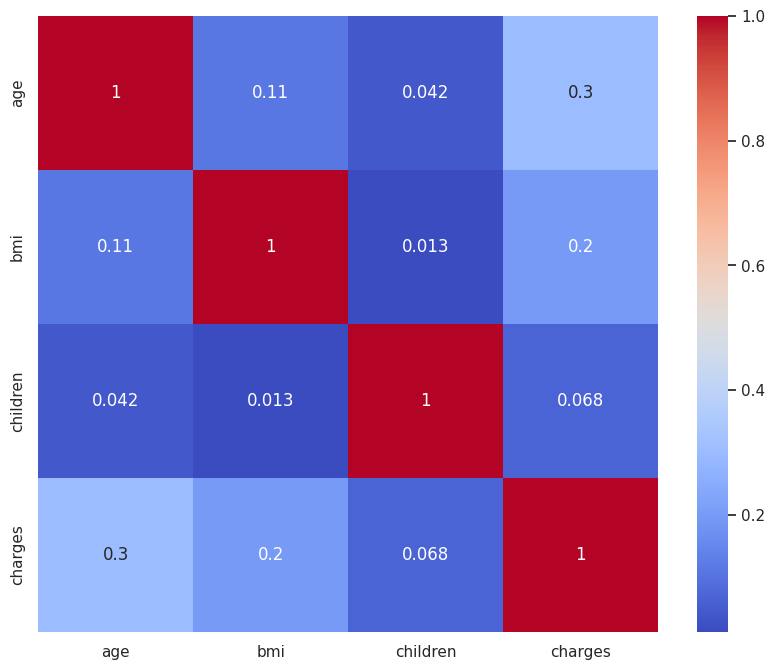

In [11]:
# Seleccionamos solo las columnas numéricas para la matriz de correlación #
data_num = data.select_dtypes(include=np.number)
# Matriz de correlación #
corr = data_num.corr()
corr
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

**Interpretación** El análisis de correlación muestra que no existen relaciones lineales fuertes entre las variables, ya que la mayoría de los coeficientes son bajos (cercanos a 0). Sin embargo, se observa una correlación positiva moderada entre charges y age (0.3), lo que sugiere que a mayor edad, tienden a aumentar los costos médicos. También se evidencia una relación positiva más débil entre charges y bmi (0.2), indicando que el índice de masa corporal podría influir ligeramente en los cargos. Por otro lado, la variable children presenta correlaciones muy bajas con las demás, lo que sugiere que tiene poca influencia en los costos. En general, estas relaciones indican que el comportamiento de charges no depende fuertemente de una sola variable, sino posiblemente de la combinación de varias, lo cual es importante para el modelado.

**2.7 Análisis de relaciones entre variables**

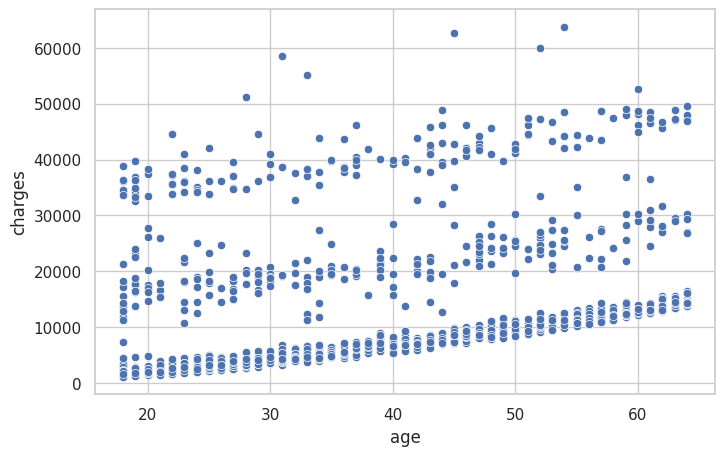

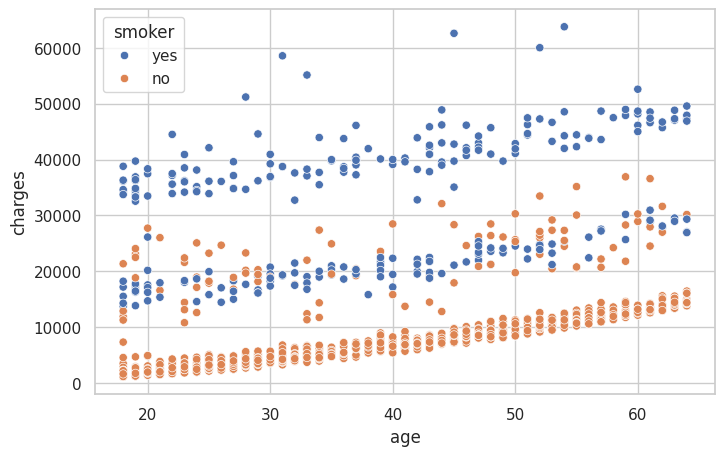

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gráfico de dispersión con dos variables numéricas #
sns.scatterplot(x="age", y="charges", data=data)
plt.show()
# Gráfico de dispersión con color según la variable objetivo #
sns.scatterplot(x="age", y="charges", hue="smoker", data=data)
plt.show()

**Interpretación** En el primer scatter (charges vs age) se observa una tendencia creciente, es decir, a medida que aumenta la edad, los costos médicos tienden a incrementarse. Sin embargo, la relación no es completamente lineal y se evidencian grupos o patrones en niveles, lo que sugiere que hay otras variables influyendo en los costos.

En el segundo gráfico (incluyendo smoker) se evidencia claramente que el hábito de fumar es un factor determinante: los individuos fumadores (yes) presentan costos significativamente más altos que los no fumadores (no) en casi todos los rangos de edad. Además, se observa mayor dispersión en los fumadores, lo que indica mayor variabilidad en los costos. En conjunto, esto sugiere que smoker es una variable clave para explicar charges, incluso más influyente que la edad.

### **PUNTO 3 VALIDACIÓN DE DATOS FALTANTES**

**3.1 Se valida si hay presencia de datos faltantes en nuestra base de datos**

In [13]:
# Valores nulos por columna #
data.isnull().sum()
# Porcentaje de valores nulos por columna #
(data.isnull().sum()/len(data))*100

,0
age,0.0
sex,0.0
bmi,0.0
children,0.0
smoker,0.0
region,0.0
charges,0.0


**Interpretación:** El análisis de valores nulos muestra que todas las variables presentan un 0% de datos faltantes, lo que indica que la base de datos está completamente completa y no presenta problemas de información incompleta. En consecuencia, no es necesario aplicar ningún método de imputación, ya que no hay valores ausentes que puedan afectar el análisis o el modelado posterior.

### **PUNTO 4 PRUEBAS DE ASOCIACIÓN Y DEPENDENCIA**

**4.1 Asociacion y dependencia entre variables númericas**


Las pruebas de asociación y dependencia entre variables numéricas se realizan para identificar si existe relación entre ellas y qué tan fuerte es dicha relación. Esto permite entender si cambios en una variable están asociados con cambios en otra, lo cual es clave para el análisis y la interpretación de los datos. Además, son fundamentales para el modelado, ya que ayudan a seleccionar variables relevantes, evitar multicolinealidad y mejorar la capacidad predictiva de los modelos, especialmente en regresión y análisis estadístico.

In [20]:
import pandas as pd
from scipy.stats import pearsonr

# 1. Calcular la correlación y el p-valor
coef, p_valor = pearsonr(data["age"], data["bmi"])

# 2. Crear un DataFrame elegante para mostrar los resultados
resultados_pearson = pd.DataFrame({
    "Métrica": ["Coeficiente de Correlación (r)", "P-valor (Significancia)"],
    "Valor": [f"{coef:.4f}", f"{p_valor:.4g}"]
})

# 3. Mostrar la tabla con estilo (ideal para Jupyter/Colab)
print("--- Análisis de Correlación de Pearson ---")
display(resultados_pearson.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

# Interpretación automática
if p_valor < 0.05:
    estado = " Estadísticamente significativa"
else:
    estado = " No es estadísticamente significativa"

print(f"\nResultado: {estado}")


--- Análisis de Correlación de Pearson ---


Métrica,Valor
Coeficiente de Correlación (r),0.1093
P-valor (Significancia),6.194e-05



Resultado:  Estadísticamente significativa


**Coeficiente de correlación de pearson:** El coeficiente de correlación de Pearson (r) es una prueba estadística que mide la fuerza y dirección de la relación lineal entre dos variables cuantitativas continuas.

Detalles clave sobre el coeficiente de Pearson:
Interpretación:
* r > 0 (Positiva): Al aumentar una variable, la otra también aumenta.
* r < 0 (Negativa): Al aumentar una variable, la otra disminuye.
* r = 0 : No existe una relación lineal entre las variables.
* Valores cercanos a 1 o -1: Indican una relación fuerte.
* Valores cercanos a 0: Indican una relación débil o inexistente.

**Interpretación:** El coeficiente de correlación (r = 0.1093) indica que existe una relación positiva pero muy débil entre age y bmi, es decir, a medida que aumenta la edad, el BMI tiende a aumentar ligeramente, pero la relación es prácticamente baja en términos prácticos. Por otro lado, el p-valor (6.19e-05) es menor a 0.05, lo que significa que la relación es estadísticamente significativa, es decir, no se debe al azar. Sin embargo, aunque es significativa, la fuerza de la relación es muy baja, por lo que su impacto real es limitado en el análisis o modelado.

**4.2 Asociacion y dependencia entre variables categoricas**


La asociación y dependencia entre variables categóricas se refiere a analizar si existe una relación entre dos variables cualitativas, es decir, si la distribución de una variable cambia según las categorías de la otra.

In [21]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1. Crear la tabla de contingencia
tabla = pd.crosstab(data["sex"], data["smoker"])

# 2. Ejecutar la prueba Chi-cuadrado
chi2, p, dof, expected = chi2_contingency(tabla)

# 3. Crear un DataFrame para mostrar los resultados con estilo
resultados = pd.DataFrame({
    "Métrica": ["Estadístico Chi2", "P-valor", "Grados de Libertad"],
    "Valor": [f"{chi2:.4f}", f"{p:.4f}", dof]
})

# Mostrar la tabla estilizada
print("--- Resultados de la Prueba Chi-cuadrado ---")
display(resultados.style.hide(axis='index'))

# Interpretación rápida
if p < 0.05:
    print("\n Resultado: Significativo (Existe relación entre las variables)")
else:
    print("\n Resultado: No significativo (Las variables son independientes)")


--- Resultados de la Prueba Chi-cuadrado ---


Métrica,Valor
Estadístico Chi2,7.3929
P-valor,0.0065
Grados de Libertad,1



 Resultado: Significativo (Existe relación entre las variables)


**Prueba Chi-Cuadrado:** La prueba chi-cuadrada es un método estadístico inferencial utilizado para analizar datos categóricos (nominales u ordinales). Determina si existe una diferencia significativa entre las frecuencias observadas en una muestra y las frecuencias esperadas teóricamente, evaluando si dos variables categóricas están relacionadas (asociación) o son independientes.

Un valor de chi-cuadrado alto sugiere diferencias significativas (se rechaza la hipótesis nula de independencia).

**Interpretación:** El resultado de la prueba Chi-cuadrado muestra un p-valor de 0.0065, el cual es menor a 0.05, lo que indica que existe una relación estadísticamente significativa entre las variables sex y smoker. Esto implica que estas variables no son independientes, es decir, la distribución del hábito de fumar varía según el sexo. En otras palabras, el hecho de ser hombre o mujer influye en la probabilidad de ser fumador dentro de esta base de datos, lo cual puede ser relevante para el análisis y la construcción de modelos predictivos.

**4.3 Asociacion y dependencia entre variables mixtas (ANOVA)**

In [22]:
import pandas as pd
from scipy.stats import f_oneway

# 1. Limpieza de datos (Aseguramos que sea numérico)
data['charges'] = pd.to_numeric(data['charges'].astype(str).str.replace('.', '', regex=False), errors='coerce')

# 2. Separación de grupos
grupo_no_smoker = data[data['smoker'] == 'no']['charges'].dropna()
grupo_smoker = data[data['smoker'] == 'yes']['charges'].dropna()

# 3. Ejecutar ANOVA
f_stat, p_val = f_oneway(grupo_no_smoker, grupo_smoker)

# 4. Crear el cuadro lindo para ANOVA
resultados_anova = pd.DataFrame({
    "Métrica": ["Estadístico F", "P-valor (Significancia)"],
    "Valor": [f"{f_stat:.4f}", f"{p_val:.4g}"]
})

# 5. Mostrar la tabla con estilo
print("--- 📊 Análisis de Varianza (ANOVA): Fumadores vs Cargos ---")
display(resultados_anova.style.hide(axis='index').set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white')]}
]))

# Interpretación rápida
if p_val < 0.05:
    print(f"\n Conclusión: Hay una diferencia significativa en los cargos según el hábito de fumar.")
else:
    print(f"\n Conclusión: No se encontraron diferencias significativas entre los grupos.")


--- 📊 Análisis de Varianza (ANOVA): Fumadores vs Cargos ---


Métrica,Valor
Estadístico F,91.8866
P-valor (Significancia),4.299e-21



 Conclusión: Hay una diferencia significativa en los cargos según el hábito de fumar.


**Interpretación:** El resultado del ANOVA muestra un estadístico F alto (≈ 91.89) y un p-valor extremadamente pequeño (4.29e-21), lo que indica que existe una diferencia estadísticamente significativa en los cargos (charges) entre fumadores y no fumadores. Esto significa que el hábito de fumar tiene un impacto importante sobre los costos médicos, rechazando la hipótesis nula de igualdad de medias entre los grupos. En términos prácticos, se concluye que ser fumador está asociado con mayores cargos,